ResNet50 Transfer Learning on FER2013

In [59]:

import os
import copy
import time

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
from torchvision import transforms

from collections import Counter
from PIL import Image

from tqdm.auto import tqdm
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [60]:
csv_path = "/kaggle/input/datasets/deadskull7/fer2013/fer2013.csv"
df = pd.read_csv(csv_path)

In [61]:
SEED = 42

torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [62]:
emotion_map = {
    0: "Angry",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Sad",
    5: "Surprise",
    6: "Neutral"
}


In [63]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485],
        std = [0.229]
    )
])

In [64]:
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485],
        std = [0.229]
    )
])

In [65]:
class FER2013Dataset(Dataset):

  def __init__(self, dataframe, transform= None):
    self.dataframe = dataframe
    self.transform = transform

  def __len__(self):
    return len(self.dataframe)

  def __getitem__(self, idx):
    row = self.dataframe.iloc[idx]

    label = int(row["emotion"])
    pixels = np.array(row["pixels"].split(), dtype=np.uint8)

    image = pixels.reshape(48,48)

    image = Image.fromarray(image)

    image= image.convert("RGB")

    if self.transform:
      image= self.transform(image)

    return image,label

In [66]:
counts= df["Usage"].value_counts()

train_df = df[df["Usage"]== "Training"].reset_index(drop=True)
val_df = df[df["Usage"]== "PublicTest"].reset_index(drop=True)
test_df = df[df["Usage"] == "PrivateTest"].reset_index(drop=True)

print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))

train_dataset = FER2013Dataset(
    train_df,
    transform=train_transform
)

val_dataset = FER2013Dataset(
    val_df,
    transform=test_transform
)

test_dataset = FER2013Dataset(
    test_df,
    transform=test_transform
)

Training: 28709
Validation: 3589
Testing: 3589


In [67]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

LOAD PRETRAINED RESNET50

In [68]:
from torchvision.models import resnet50, ResNet50_Weights

# Load pretrained ResNet50
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [69]:
#FREEZE THE BACKBONE

for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

model.fc = nn.Linear(2048, 7)

num_features= model.fc.in_features
model.fc = nn.Linear(num_features, 7)

model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print(f"Trainable Parameters: {trainable:,}")
print(f"Total Parameters: {total:,}")


Trainable Parameters: 14,979,079
Total Parameters: 23,522,375


LOSS FUNCTION

In [70]:
criterion = nn.CrossEntropyLoss()


Optimizer

In [71]:
optimizer = optim.Adam(
    model.fc.parameters(),
    lr= 1e-4
)
print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


In [72]:
NUM_EPOCHS = 10
LEARNING_RATE = 0.001
BATCH_SIZE = 32

BEST_MODEL_PATH = "best_resnet50.pth"

Training function

In [73]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(dataloader, desc="Training"):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(dataloader.dataset)

    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [74]:
def validate_one_epoch(model, dataloader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in tqdm(dataloader, desc="Validation"):

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [75]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs,
    device
):

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_val_acc = 0.0

    for epoch in range(epochs):

        print(f"\nEpoch {epoch+1}/{epochs}")

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_acc = validate_one_epoch(
            model,
            val_loader,
            criterion,
            device
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Train Loss : {train_loss:.4f}")
        print(f"Train Acc  : {train_acc:.4f}")
        print(f"Val Loss   : {val_loss:.4f}")
        print(f"Val Acc    : {val_acc:.4f}")

        if val_acc > best_val_acc:

            best_val_acc = val_acc

            torch.save(model.state_dict(), "best_resnet50.pth")

            print("Best model saved.")

    return history

In [76]:
history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    NUM_EPOCHS,
    device
)


Epoch 1/10


Training:   0%|          | 0/898 [00:00<?, ?it/s]

KeyboardInterrupt: 

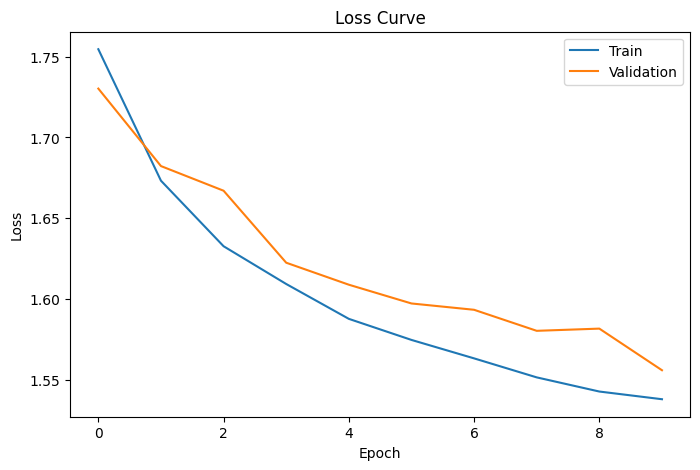

<Figure size 640x480 with 0 Axes>

In [78]:
plt.figure(figsize=(8,5))

plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")

plt.legend()

plt.show()

plt.savefig("/kaggle/working/plots/resnet50_loss.png",
            dpi=300,
            bbox_inches="tight")


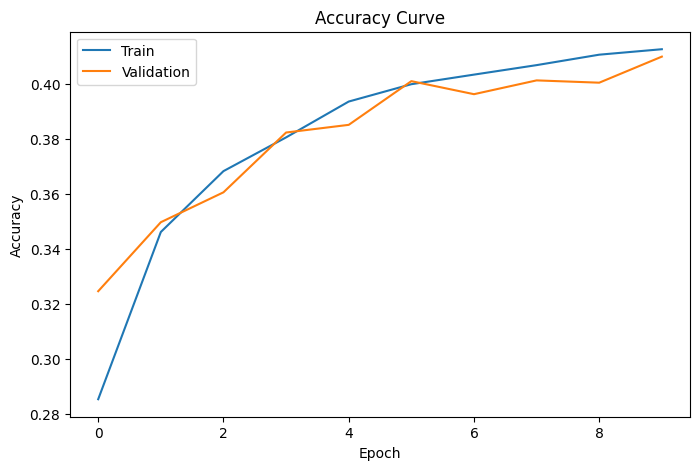

<Figure size 640x480 with 0 Axes>

In [77]:
plt.figure(figsize=(8,5))

plt.plot(history["train_acc"], label="Train")
plt.plot(history["val_acc"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")

plt.legend()

plt.show()

plt.savefig("/kaggle/working/plots/resnet50_accuracy.png",
            dpi=300,
            bbox_inches="tight")

MODEL EVALUATION

In [ ]:
def evaluate_model(model, dataloader, device):

    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in tqdm(dataloader, desc="Evaluating"):

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(preds.cpu().numpy())

    return all_labels, all_predictions

In [50]:
def evaluate_model(model, dataloader, device):

    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in tqdm(dataloader, desc="Evaluating"):

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(preds.cpu().numpy())

    return all_labels, all_predictions

In [51]:
y_true, y_pred = evaluate_model(
    model,
    test_loader,
    device
)

Evaluating:   0%|          | 0/113 [00:00<?, ?it/s]

In [52]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.4152
Precision: 0.3861
Recall   : 0.4152
F1 Score : 0.3804


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [53]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=[
        "Angry",
        "Disgust",
        "Fear",
        "Happy",
        "Sad",
        "Surprise",
        "Neutral"
    ]
))

              precision    recall  f1-score   support

       Angry       0.31      0.20      0.24       491
     Disgust       0.00      0.00      0.00        55
        Fear       0.27      0.15      0.19       528
       Happy       0.44      0.80      0.57       879
         Sad       0.40      0.28      0.33       594
    Surprise       0.50      0.61      0.55       416
     Neutral       0.42      0.31      0.36       626

    accuracy                           0.42      3589
   macro avg       0.33      0.33      0.32      3589
weighted avg       0.39      0.42      0.38      3589



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


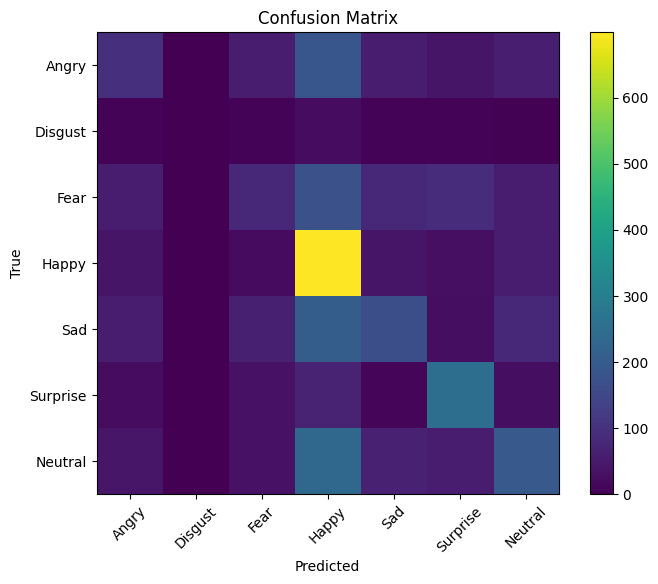

<Figure size 640x480 with 0 Axes>

In [79]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

plt.imshow(cm, interpolation="nearest")

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks(range(7), emotion_map.values(), rotation=45)
plt.yticks(range(7), emotion_map.values())

plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

plt.savefig("/kaggle/working/confusion_matrices/resnet50_cm.png",
            dpi=300,
            bbox_inches="tight")

In [56]:
import os

# Create output folders
folders = [
    "/kaggle/working/plots",
    "/kaggle/working/confusion_matrices",
    "/kaggle/working/reports",
    "/kaggle/working/results"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [58]:
import os

print(os.listdir("/kaggle/working"))

['reports', 'plots', 'best_resnet50.pth', '.virtual_documents', 'results', 'confusion_matrices']


In [81]:
class_names = [emotion_map[i] for i in range(len(emotion_map))]
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

with open("/kaggle/working/reports/resnet50_report.txt", "w") as f:
    f.write(report)

              precision    recall  f1-score   support

       Angry       0.31      0.20      0.24       491
     Disgust       0.00      0.00      0.00        55
        Fear       0.27      0.15      0.19       528
       Happy       0.44      0.80      0.57       879
         Sad       0.40      0.28      0.33       594
    Surprise       0.50      0.61      0.55       416
     Neutral       0.42      0.31      0.36       626

    accuracy                           0.42      3589
   macro avg       0.33      0.33      0.32      3589
weighted avg       0.39      0.42      0.38      3589



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Results

### ResNet50 Baseline

Accuracy:

Precision:

Recall:

F1-score:

Observations:

- The model performed well on ______.
- The model struggled to distinguish ______ and ______.
- Class imbalance likely affected the performance of the "Disgust" class.